In [1]:
# RAG를 운영 : LangChain + LangGraph
# 사용자가 질문을 -> LLM이 답변/요약 -> 요약 결과 출력
!pip install langgraph langchain-openai python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 3.3 MB/s eta 0:00:00


prompt : 
    너는 친절한 한국어 질문 챗봇이야.
    아래 질문에 대해 10문장 이내로 설명해줘.
    질문 : 양자 컴퓨팅이 뭐야? 중학생도 이해할 수 있는 수준으로 설명해줘
  
질문 : 양자 컴퓨팅이 뭐야? 중학생도 이해할 수 있는 수준으로 설명해줘
LLM의 답변 : 양자 컴퓨팅은 매우 빠르고 강력한 컴퓨터 기술을 의미해. 일반 컴퓨터는 정보를 비트라고 불리는 작은 단위로 처리해. 비트는 0 또는 1의 값을 가질 수 있어. 반면, 양자 컴퓨터는 큐비트라는 특별한 단위를 사용해. 큐비트는 0과 1을 동시에 가질 수 있어, 이를 '중첩'이라고 해.

이 덕분에 양자 컴퓨터는 복잡한 문제를 더 빨리 해결할 수 있어. 예를 들어, 매우 큰 숫자를 곱하거나 분해할 때 일반 컴퓨터보다 훨씬 효과적이야. 또 양자 얽힘이라는 현상을 이용해서 여러 큐비트를 연결할 수도 있어. 이러한 특성 덕분에 양자 컴퓨터는 미래의 기술에 큰 영향을 미칠 것으로 기대되고 있어. 요약하자면, 양자 컴퓨팅은 새로운 종류의 컴퓨터 기술로, 정보 처리 속도가 빠르고 더 복잡한 문제를 해결할 수 있는 방법이야.
요약:양자 컴퓨팅은 매우 빠르고 강력한 컴퓨터 기술을 의미해. 일반 컴퓨터는 ...


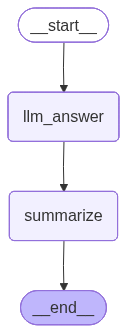

In [6]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError("OPENAI_API_KEY is not set")

llm = ChatOpenAI(model_name="gpt-4o-mini", openai_api_key=OPENAI_API_KEY)

# State 정의
class QAState(TypedDict):
    question: str
    answer: str
    summary: str

# Node 정의
def node_llm_answer(state:QAState) -> QAState:
  question = state["question"]
  prompt=f"""
    너는 친절한 한국어 질문 챗봇이야.
    아래 질문에 대해 10문장 이내로 설명해줘.
    질문 : {question}
  """
  print(f"prompt : {prompt}")
  resp = llm.invoke(prompt)
  answer_text = resp.content

  return {
      **state,
      "answer": answer_text,
      }


def node_summarize(state:QAState) -> QAState:
  # LLM이 요약하도록 해야 하지만, 편의상 답변의 앞 일부분만 요약처럼 보여주기
  answer = state["answer"]
  short = answer.strip().replace("\n", " ")

  if len(short) > 100:
    short = short[:40] + "..."

  summary = f"요약 : {short}"

  return {
      **state,
      "summary": summary,
      }

# Graph 구성
def build_graph():
  graph = StateGraph(QAState)

  graph.add_node("llm_answer", node_llm_answer)
  graph.add_node("summarize", node_summarize)

  graph.set_entry_point("llm_answer")

  graph.add_edge("llm_answer", "summarize")
  graph.add_edge("summarize", END)

  return graph.compile()

if __name__=="__main__":
  app = build_graph()

  init_state:QAState = {
      "question":"양자 컴퓨팅이 뭐야? 중학생도 이해할 수 있는 수준으로 설명해줘"
  }

  final_state = app.invoke(init_state)
  print(f"질문 : {final_state["question"]}")

  print(f"LLM의 답변 : {final_state["answer"]}")

  print(final_state["summary"])

  from IPython.display import Image, display
  g = app.get_graph()
  png_bytes = g.draw_mermaid_png()
  display(Image(data=png_bytes))
